In [1]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# Convolution + Pooling
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Fully Connected
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))

loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 41ms/step - accuracy: 0.4747 - loss: 1.4712 - val_accuracy: 0.5237 - val_loss: 1.3692
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.6084 - loss: 1.1183 - val_accuracy: 0.6280 - val_loss: 1.0556
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.6596 - loss: 0.9739 - val_accuracy: 0.6635 - val_loss: 0.9674
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6929 - loss: 0.8851 - val_accuracy: 0.6558 - val_loss: 0.9987
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.7161 - loss: 0.8217 - val_accuracy: 0.6801 - val_loss: 0.9447
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7366 - loss: 0.7613 - val_accuracy: 0.6862 - val_loss: 0.9227
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 41ms/step - accuracy: 0.7525 - loss: 0.7106 - val_accuracy: 0.6994 - val_loss: 0.9009
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.7687 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


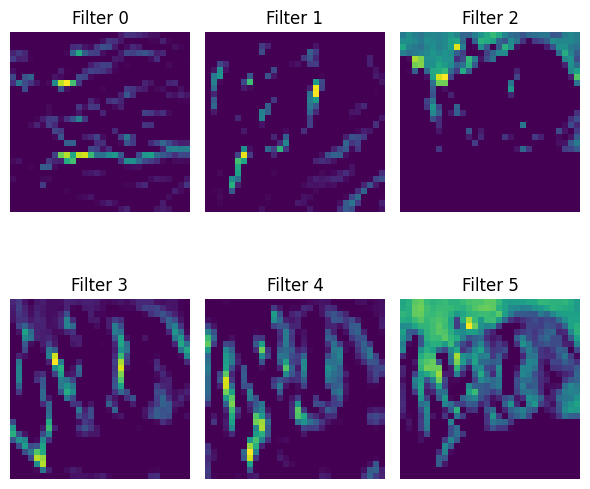

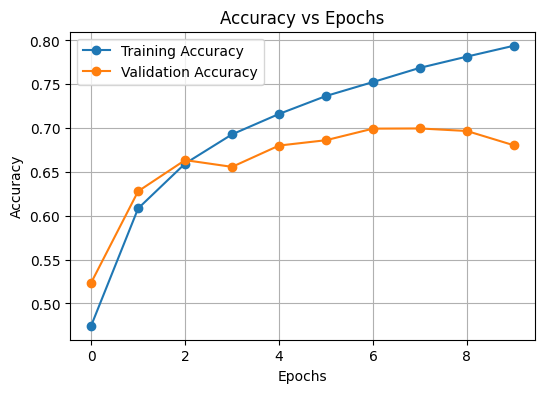

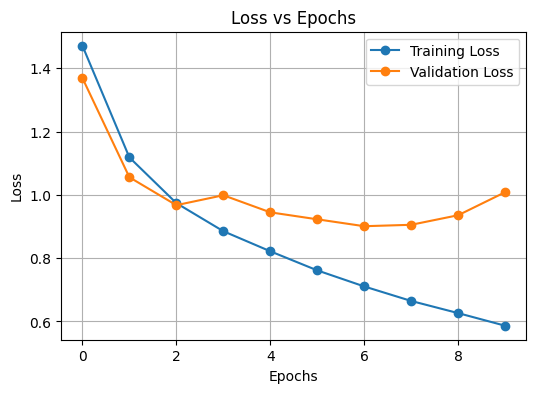

In [4]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# ✅ Build model (IMPORTANT)
model(x_test[:1])

# ✅ Extract first convolution layer
layer_output = model.layers[0].output

# ✅ Create activation model
activation_model = Model(inputs=model.inputs, outputs=layer_output)

# ✅ Get feature maps
feature_maps = activation_model.predict(x_test[:1])

# 🔍 FEATURE MAPS (clean + labeled)
plt.figure(figsize=(6,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[0][:,:,i], cmap='viridis')
    plt.title(f"Filter {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()


# 📈 ACCURACY GRAPH (improved)
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.grid()
plt.show()


# 📉 LOSS GRAPH (optional but good for record)
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')

plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])

plt.grid()
plt.show()